# Automated annotation: CellAssign

In [1]:
import os
import tempfile

import matplotlib.pyplot as plt
import pandas as pd
import scanpy as sc
import scvi
import seaborn as sns
import torch
from scvi.external import CellAssign

/opt/conda/lib/python3.11/site-packages/anndata/utils.py:429: FutureWarning: Importing read_csv from `anndata` is deprecated. Import anndata.io.read_csv instead.
  warnings.warn(msg, FutureWarning)
/opt/conda/lib/python3.11/site-packages/anndata/utils.py:429: FutureWarning: Importing read_excel from `anndata` is deprecated. Import anndata.io.read_excel instead.
  warnings.warn(msg, FutureWarning)
/opt/conda/lib/python3.11/site-packages/anndata/utils.py:429: FutureWarning: Importing read_hdf from `anndata` is deprecated. Import anndata.io.read_hdf instead.
  warnings.warn(msg, FutureWarning)
/opt/conda/lib/python3.11/site-packages/anndata/utils.py:429: FutureWarning: Importing read_loom from `anndata` is deprecated. Import anndata.io.read_loom instead.
  warnings.warn(msg, FutureWarning)
/opt/conda/lib/python3.11/site-packages/anndata/utils.py:429: FutureWarning: Importing read_mtx from `anndata` is deprecated. Import anndata.io.read_mtx instead.
  warnings.warn(msg, FutureWarning)
/opt

In [2]:
scvi.settings.seed = 0
print("Last run with scvi-tools version:", scvi.__version__)

Seed set to 0


Last run with scvi-tools version: 1.2.0


In [3]:
sc.set_figure_params(figsize=(6, 6), frameon=False)
sns.set_theme()
torch.set_float32_matmul_precision("high")
#save_dir = tempfile.TemporaryDirectory()

%config InlineBackend.print_figure_kwargs={"facecolor": "w"}
%config InlineBackend.figure_format="retina"

In [4]:
l1 = sc.read('L1_annotation.h5ad')
l2 = sc.read('L2_annotation.h5ad')

celltype_markers = pd.read_csv('/home/sources/atlases/panel.tsv', sep='\t', skiprows=0)
celltype_markers = celltype_markers[~celltype_markers['Cell type'].isna()]
celltype_markers = celltype_markers[['TAIR', 'Cell type']].drop_duplicates()
# celltype_markers = celltype_markers[celltype_markers['Cell type'] != 'cambium']
# celltype_markers = celltype_markers[celltype_markers['Cell type'] != 'sieve element']

celltype_markers = celltype_markers.set_index('TAIR')
celltype_markers = celltype_markers.pivot(columns='Cell type', values='Cell type')
celltype_markers[~celltype_markers.isna()] = 1
celltype_markers[celltype_markers.isna()] = 0
celltype_markers['unknown'] = 0
celltype_markers = celltype_markers.astype(int)

l1.obs.index = l1.obs.index.astype("str")
l1.var.index = l1.var.index.astype("str")
l1.var_names_make_unique()
l1.obs_names_make_unique()

l2.obs.index = l2.obs.index.astype("str")
l2.var.index = l2.var.index.astype("str")
l2.var_names_make_unique()
l2.obs_names_make_unique()

l1

AnnData object with n_obs × n_vars = 4071 × 16321
    obs: 'n_count', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_20_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_cp', 'log1p_total_counts_cp', 'pct_counts_cp', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'outlier', 'mt_outlier', 'cp_outlier', 'n_genes', 'scDblFinder_score', 'scDblFinder_class', 'size_factors', 'pp_score', 'S_score', 'G2M_score', 'phase', 'leiden_res0_25', 'leiden_res0_5', 'leiden_res1', 'leiden_res0_75', 'manual_celltype_annotation'
    var: 'gene_ids', 'mt', 'cp', 'ribo', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'n_cells', 'highly_deviant', 'binomial_deviance', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'mean', 'std'
    uns: 'dea_leiden_0_5', 'dendrogram_leiden_res0_5', 'hvg', 'leiden_res0_25', 'leiden

In [5]:
celltype_markers

Cell type,G2/M phase,S phase,bundle sheath,cambium,companion cell,epidermis,guard cell,meristem,mesophyll,myrosin idioblasts,pavement cell,phloem,phloem parenchyma,proliferating cell,sieve element,tracheary element,vasculature,xylem,unknown
TAIR,,,,,,,,,,,,,,,,,,,
AT1G06360,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0
AT1G06490,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0
AT1G07370,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
AT1G07640,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0
AT1G08810,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
AT5G61480,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0
AT5G624701,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0
AT5G62940,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0


In [6]:
shared_genes_l1 = l1.var_names.intersection(celltype_markers.index)
shared_genes_l2 = l2.var_names.intersection(celltype_markers.index)

In [7]:
l1_bdata = l1[:, shared_genes_l1].copy()
l2_bdata = l2[:, shared_genes_l2].copy()

## L1 

In [8]:
scvi.external.CellAssign.setup_anndata(l1_bdata, layer='counts', size_factor_key="size_factors")

In [9]:
l1_model = CellAssign(l1_bdata, celltype_markers.loc[shared_genes_l1, :])
l1_model.train()

GPU available: False, used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
/opt/conda/lib/python3.11/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:424: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=23` in the `DataLoader` to improve performance.
/opt/conda/lib/python3.11/site-packages/lightning/pytorch/loops/fit_loop.py:298: The number of training batches (4) is smaller than the logging interval Trainer(log_every_n_steps=10). Set a lower value for log_every_n_steps if you want to see logs for the training epoch.
/opt/conda/lib/python3.11/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:424: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=23` in the `DataLoader` to improve performance.


Epoch 400/400: 100%|██████████| 400/400 [15:23<00:00,  2.06s/it, v_num=1, train_loss_step=14.7, train_loss_epoch=15.2]

`Trainer.fit` stopped: `max_epochs=400` reached.


Epoch 400/400: 100%|██████████| 400/400 [15:23<00:00,  2.31s/it, v_num=1, train_loss_step=14.7, train_loss_epoch=15.2]


<Axes: xlabel='epoch'>

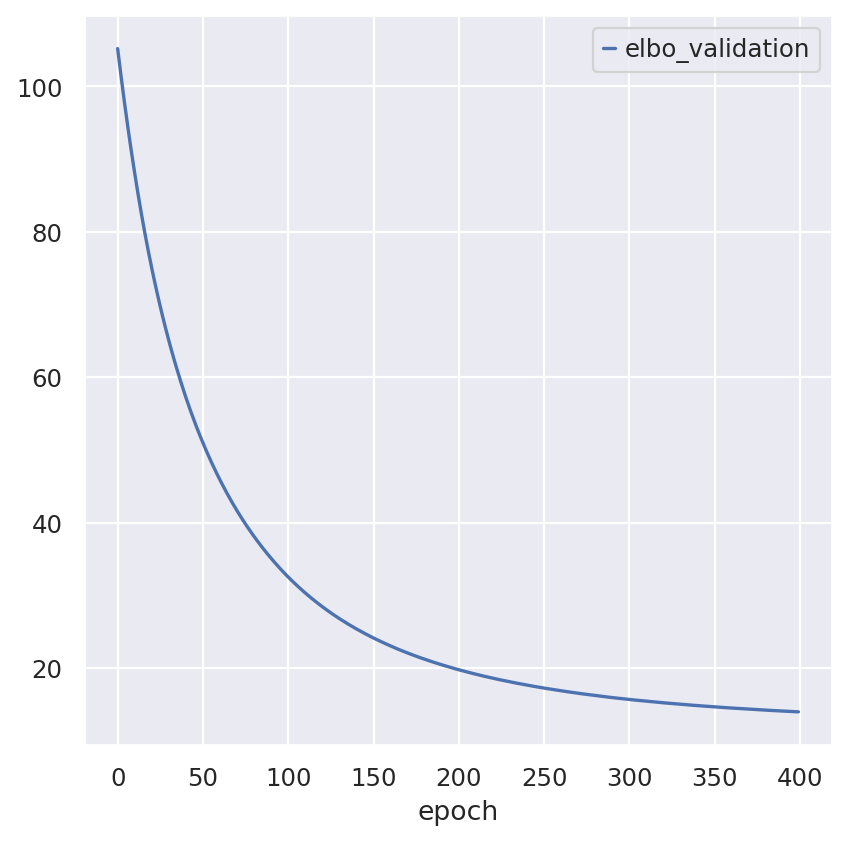

In [10]:
l1_model.history["elbo_validation"].plot()

In [11]:
predictions = l1_model.predict()
predictions.head()

Cell type,G2/M phase,S phase,bundle sheath,cambium,companion cell,epidermis,guard cell,meristem,mesophyll,myrosin idioblasts,pavement cell,phloem,phloem parenchyma,proliferating cell,sieve element,tracheary element,vasculature,xylem,unknown
0,0.001161,0.000029,0.002107,0.992355,0.000043,5.100347e-07,0.000120,0.000004,0.000006,0.000008,2.485009e-06,0.000191,0.000153,0.000006,1.868999e-06,0.002324,0.000008,0.000007,0.001472
1,0.001160,0.000037,0.002107,0.992119,0.000047,1.001280e-06,0.000129,0.000005,0.000003,0.000009,3.450560e-06,0.000206,0.000163,0.000008,2.729682e-06,0.002323,0.000196,0.000010,0.001472
2,0.001160,0.000013,0.002106,0.991616,0.000034,2.808029e-07,0.000099,0.000002,0.000007,0.000005,8.871923e-07,0.000155,0.000589,0.000003,6.568450e-07,0.002322,0.000414,0.000003,0.001471
3,0.001160,0.000146,0.002107,0.992185,0.000035,1.117594e-05,0.000101,0.000002,0.000032,0.000006,9.982544e-07,0.000159,0.000131,0.000003,7.323312e-07,0.002323,0.000122,0.000003,0.001472
4,0.001159,0.000274,0.002104,0.990786,0.000044,5.336021e-07,0.000122,0.000004,0.000035,0.000008,2.677344e-06,0.000194,0.000155,0.000006,2.033430e-06,0.002320,0.001306,0.000008,0.001470


/opt/conda/lib/python3.11/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)
/opt/conda/lib/python3.11/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)


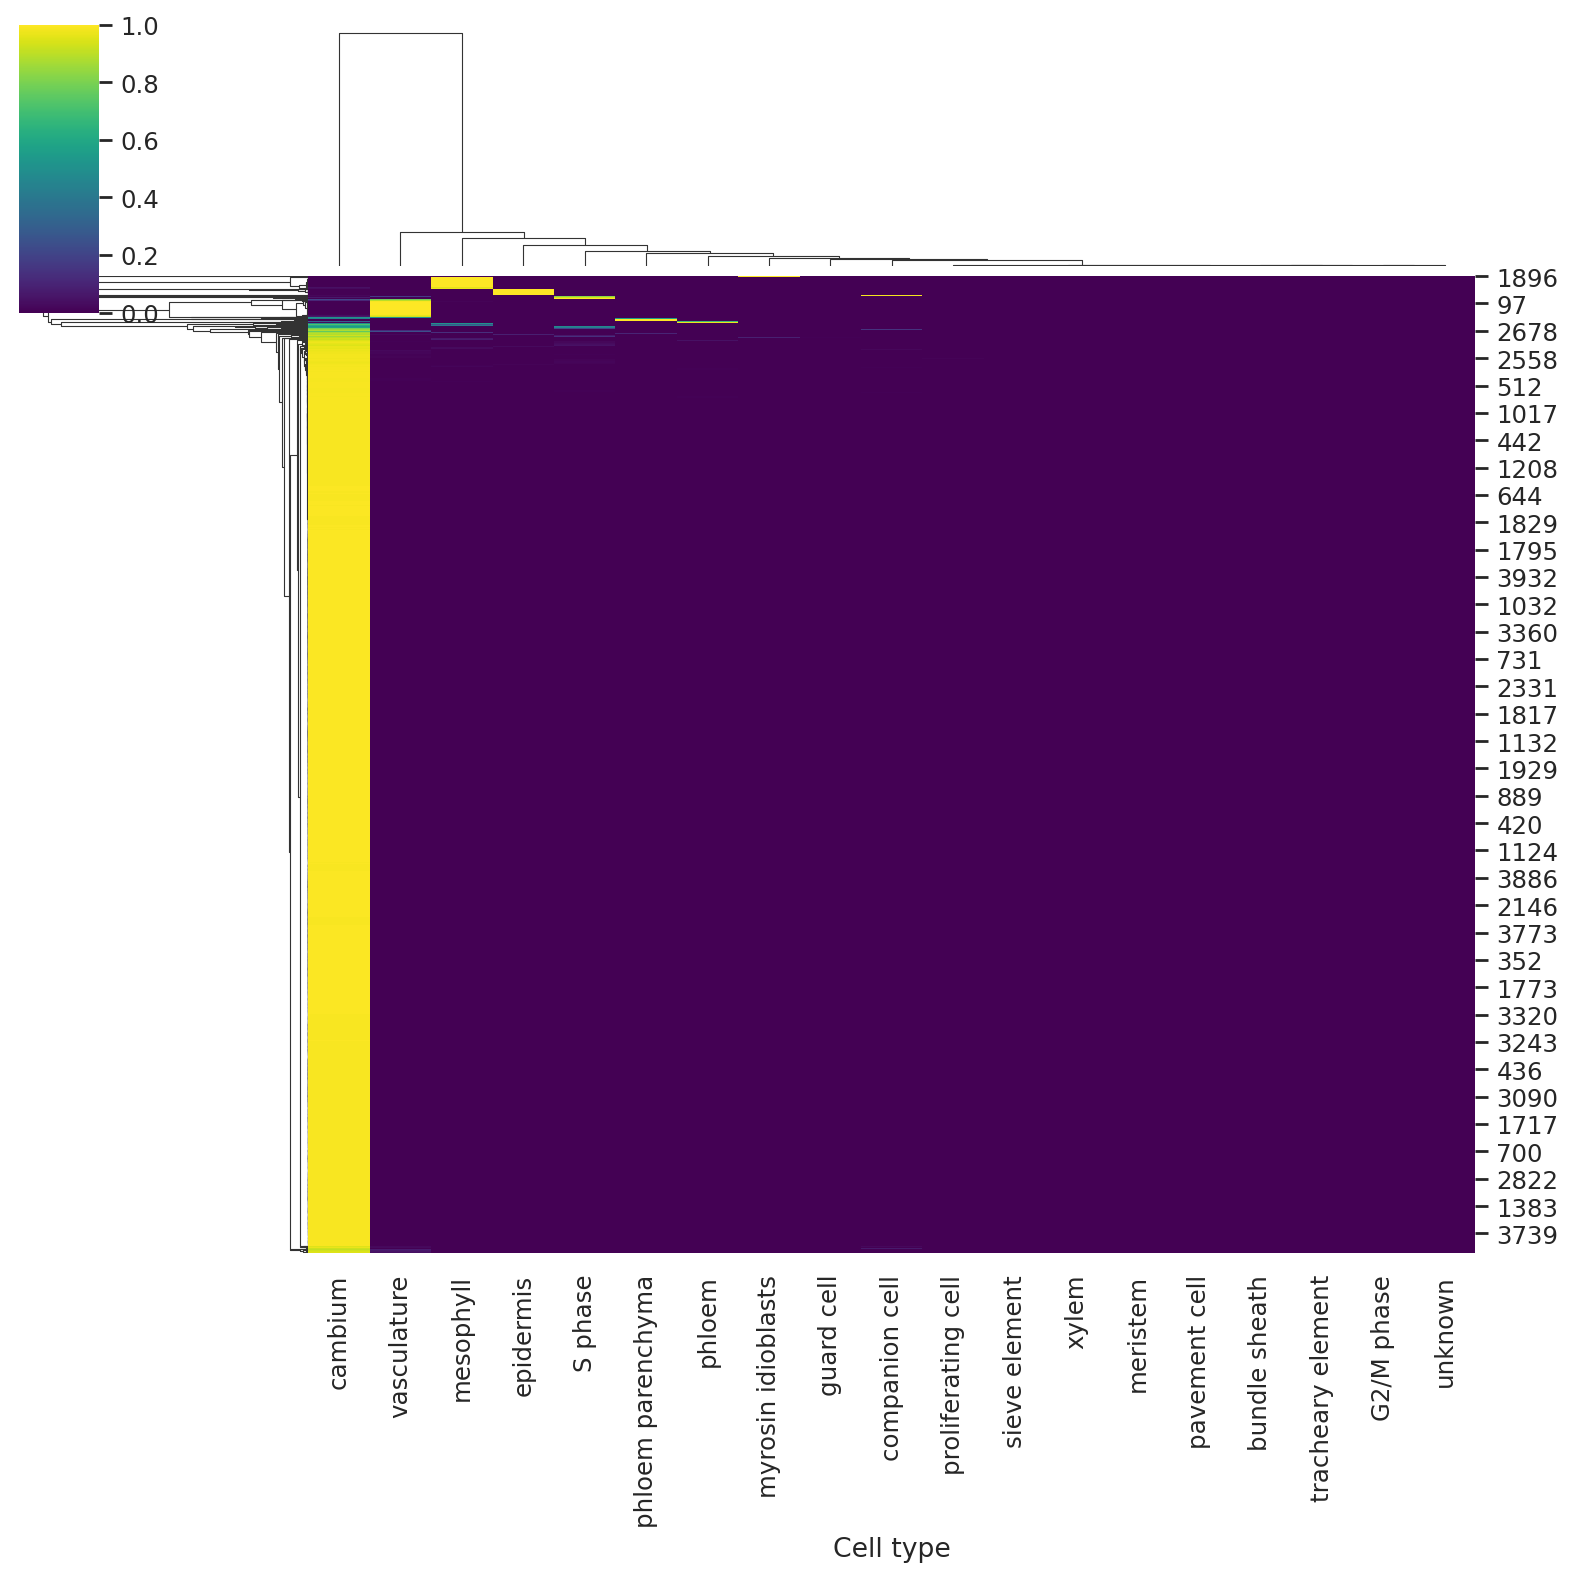

In [12]:
sns.clustermap(predictions, cmap="viridis")

In [13]:
l1_bdata.obs["cellassign_predictions"] = predictions.idxmax(axis=1).values

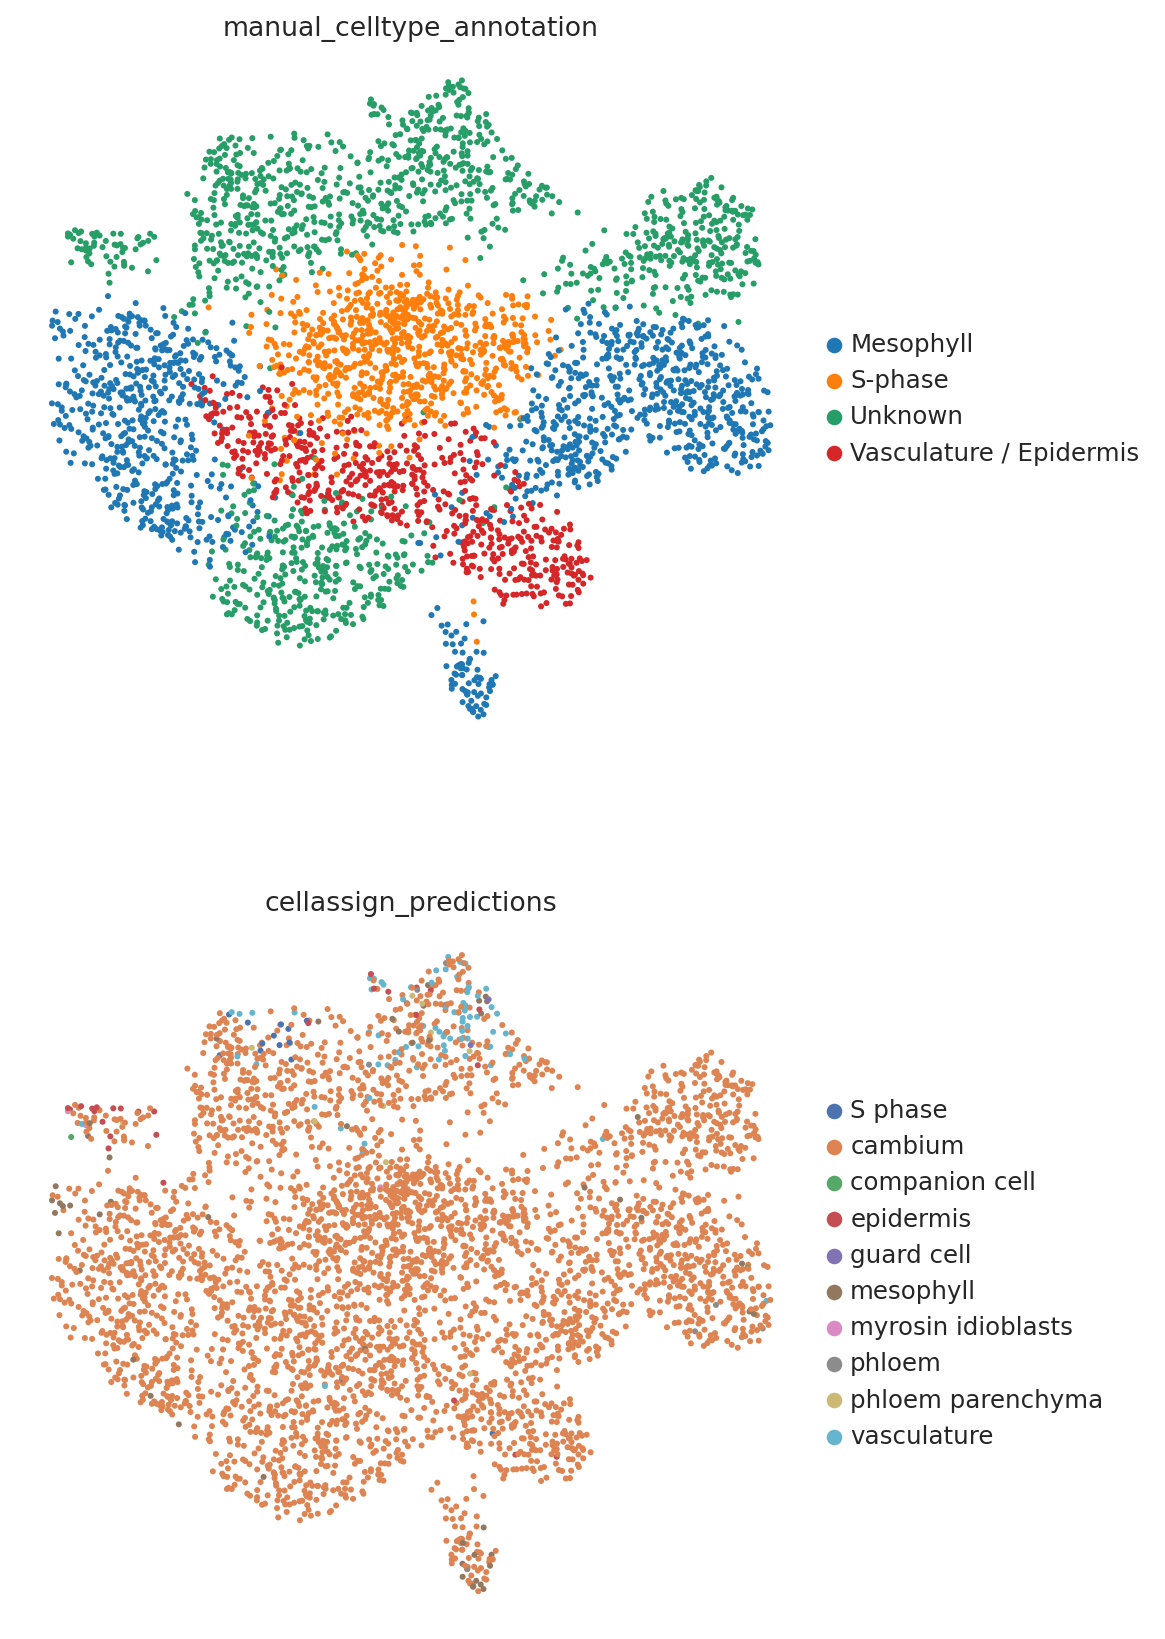

In [14]:
# celltype is the original CellAssign prediction
sc.pl.umap(
    l1_bdata,
    color=["manual_celltype_annotation", "cellassign_predictions"],
    frameon=False,
    ncols=1,
)

## L2

In [15]:
scvi.external.CellAssign.setup_anndata(l2_bdata, layer='counts', size_factor_key="size_factors")

In [16]:
l2_model = CellAssign(l2_bdata, celltype_markers.loc[shared_genes_l2, :])
l2_model.train()

GPU available: False, used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
/opt/conda/lib/python3.11/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:424: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=23` in the `DataLoader` to improve performance.
/opt/conda/lib/python3.11/site-packages/lightning/pytorch/loops/fit_loop.py:298: The number of training batches (3) is smaller than the logging interval Trainer(log_every_n_steps=10). Set a lower value for log_every_n_steps if you want to see logs for the training epoch.
/opt/conda/lib/python3.11/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:424: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=23` in the `DataLoader` to improve performance.


Epoch 1/400:   0%|          | 0/400 [00:00<?, ?it/s]

Epoch 400/400: 100%|██████████| 400/400 [10:45<00:00,  1.81s/it, v_num=1, train_loss_step=19.3, train_loss_epoch=18.9]

`Trainer.fit` stopped: `max_epochs=400` reached.


Epoch 400/400: 100%|██████████| 400/400 [10:45<00:00,  1.61s/it, v_num=1, train_loss_step=19.3, train_loss_epoch=18.9]


<Axes: xlabel='epoch'>

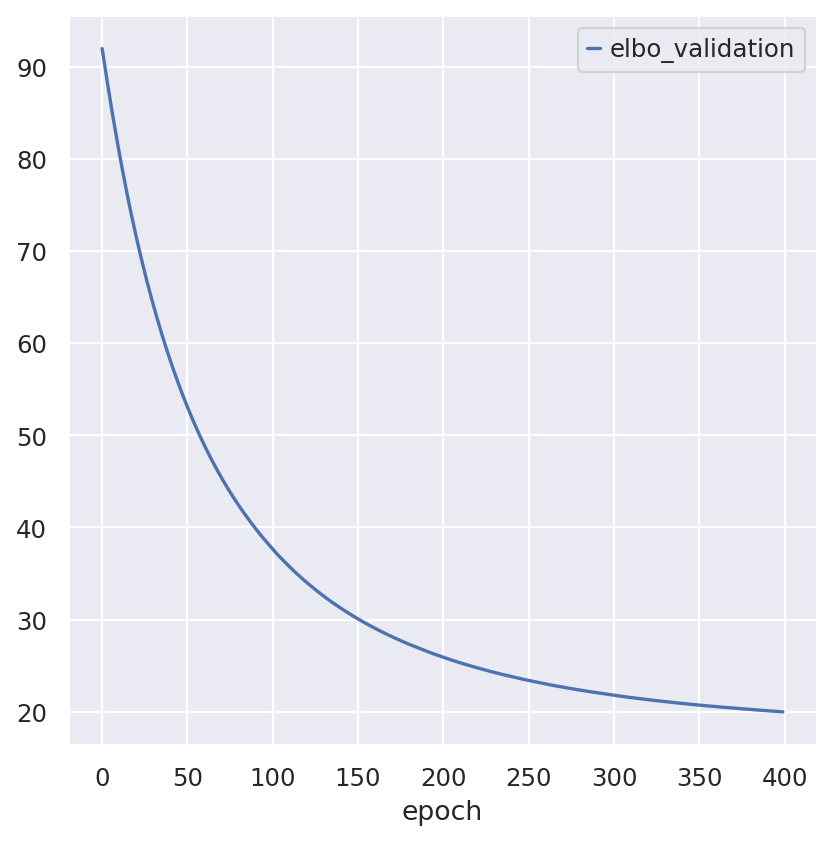

In [17]:
l2_model.history["elbo_validation"].plot()

In [18]:
predictions = l2_model.predict()
predictions.head()

Cell type,G2/M phase,S phase,bundle sheath,cambium,companion cell,epidermis,guard cell,meristem,mesophyll,myrosin idioblasts,pavement cell,phloem,phloem parenchyma,proliferating cell,sieve element,tracheary element,vasculature,xylem,unknown
0,0.001421,0.000019,0.000967,2.311521e-06,0.000040,1.255344e-06,6.627036e-07,0.000088,0.000077,0.000034,2.410772e-06,0.000042,0.000092,0.000077,4.632839e-06,1.401721e-06,0.000006,0.000161,0.996964
1,0.001418,0.000006,0.000966,6.751364e-07,0.000031,1.110614e-06,2.232904e-07,0.000071,0.000051,0.000025,6.944976e-07,0.000034,0.000074,0.000061,1.363034e-06,5.123929e-07,0.001700,0.000127,0.995430
2,0.001420,0.000027,0.000967,3.613273e-06,0.000043,1.165019e-04,1.066783e-06,0.000095,0.000090,0.000037,3.835141e-06,0.000045,0.000099,0.000084,7.312810e-06,2.200734e-06,0.000022,0.000175,0.996760
3,0.001421,0.000003,0.000968,3.491139e-07,0.000027,3.453507e-07,1.443714e-07,0.000063,0.000040,0.000021,3.657392e-07,0.000030,0.000066,0.000054,7.267373e-07,3.497509e-07,0.000018,0.000111,0.997177
4,0.001410,0.007337,0.000960,1.017740e-06,0.000034,2.706581e-06,3.088870e-07,0.000076,0.000059,0.000028,1.045323e-06,0.000036,0.000079,0.000066,2.036832e-06,6.879056e-07,0.000009,0.000137,0.989761


/opt/conda/lib/python3.11/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)
/opt/conda/lib/python3.11/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)


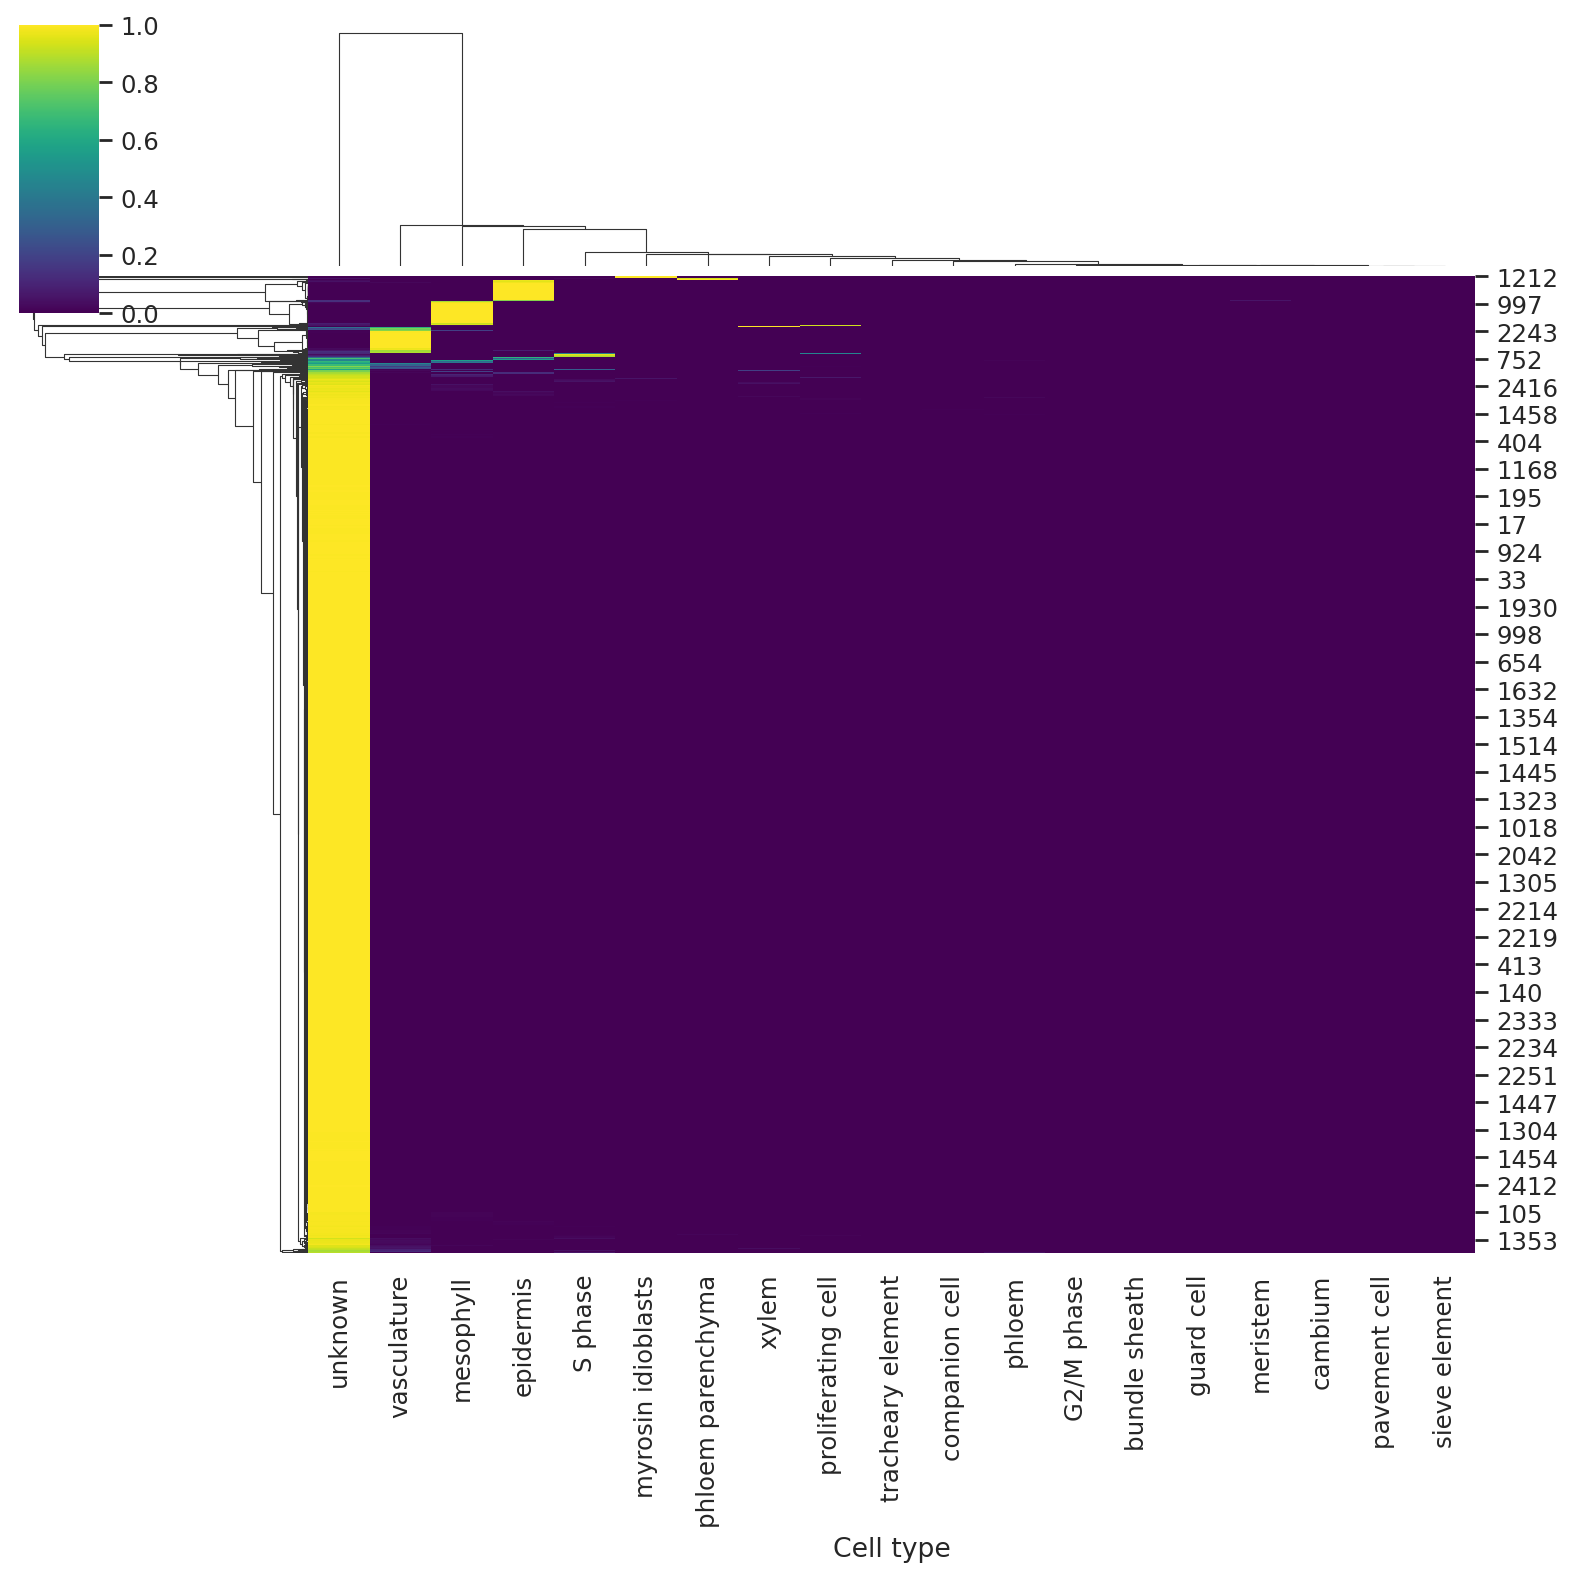

In [19]:
sns.clustermap(predictions, cmap="viridis")

In [20]:
l2_bdata.obs["cellassign_predictions"] = predictions.idxmax(axis=1).values

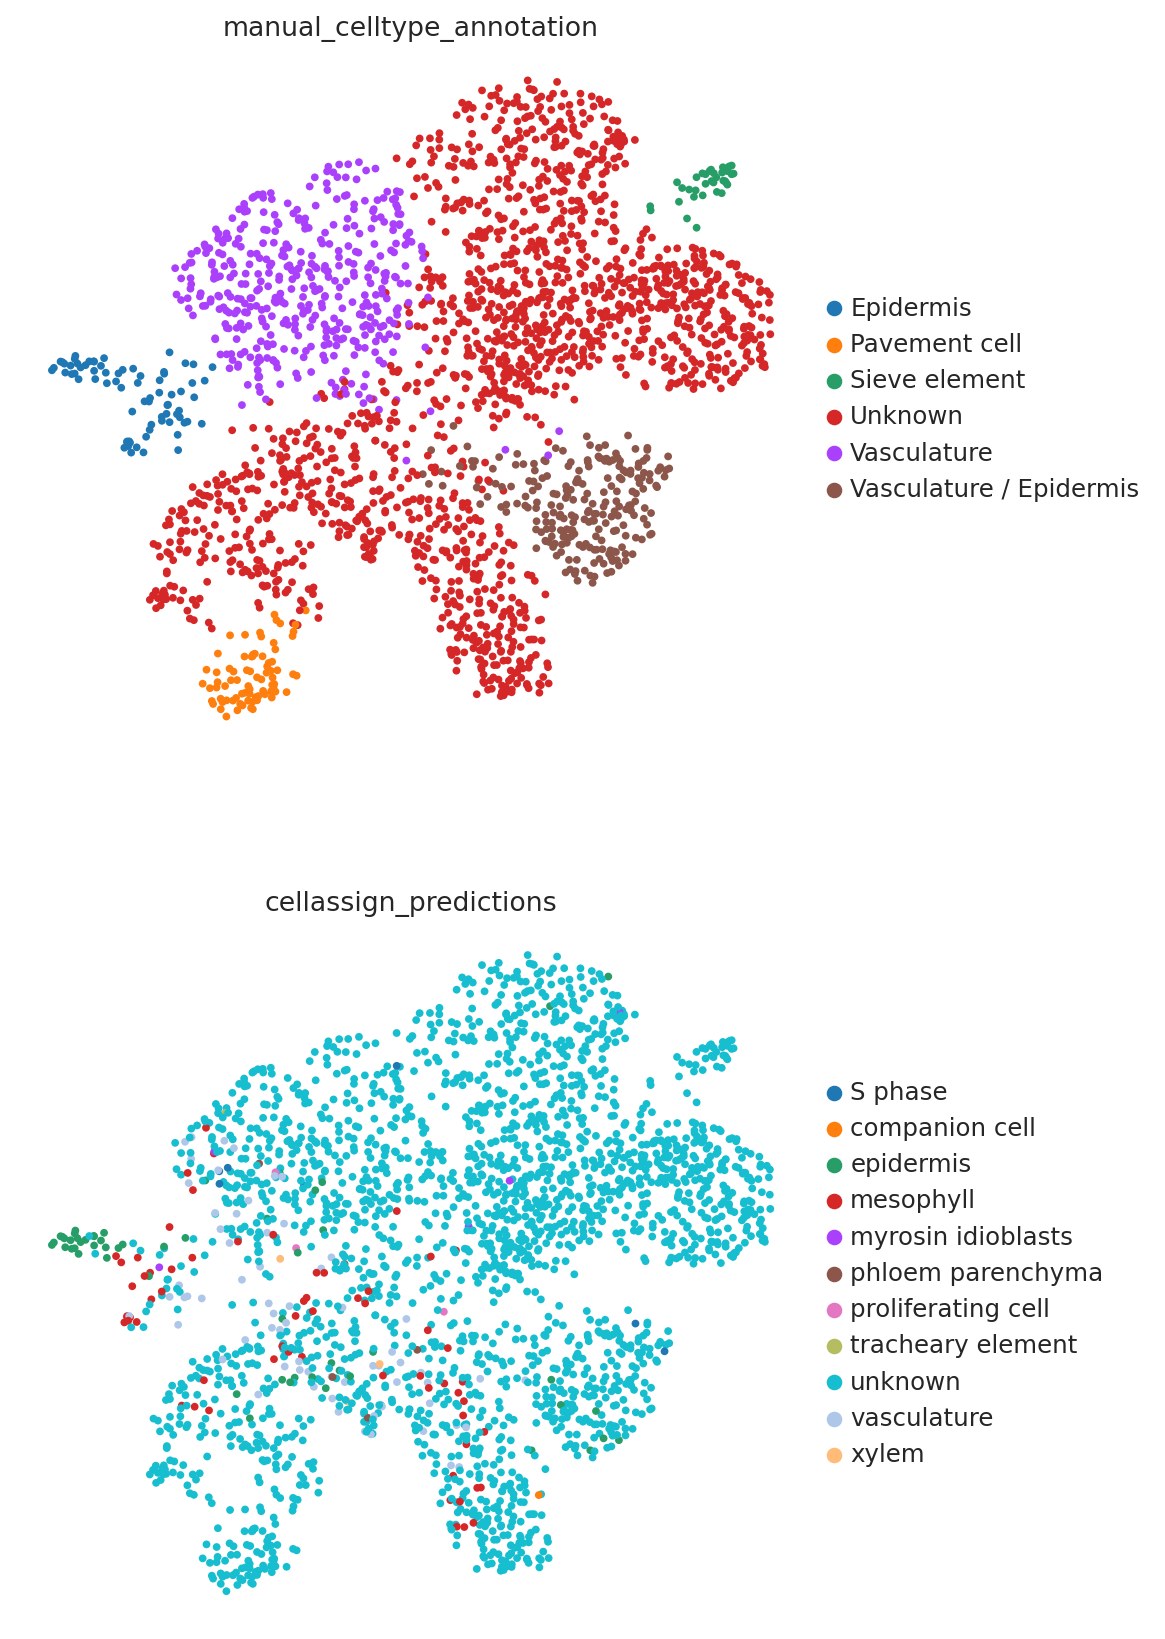

In [21]:
# celltype is the original CellAssign prediction
sc.pl.umap(
    l2_bdata,
    color=["manual_celltype_annotation", "cellassign_predictions"],
    frameon=False,
    ncols=1,
)

## L1 on SoupX layer

In [22]:
scvi.external.CellAssign.setup_anndata(l1_bdata, layer='soupX_counts', size_factor_key="size_factors")

In [23]:
l1_model = CellAssign(l1_bdata, celltype_markers.loc[shared_genes_l1, :])
l1_model.train()

GPU available: False, used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
/opt/conda/lib/python3.11/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:424: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=23` in the `DataLoader` to improve performance.
/opt/conda/lib/python3.11/site-packages/lightning/pytorch/loops/fit_loop.py:298: The number of training batches (4) is smaller than the logging interval Trainer(log_every_n_steps=10). Set a lower value for log_every_n_steps if you want to see logs for the training epoch.
/opt/conda/lib/python3.11/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:424: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=23` in the `DataLoader` to improve performance.


Epoch 21/400:   5%|▌         | 20/400 [00:51<16:22,  2.59s/it, v_num=1, train_loss_step=62.5, train_loss_epoch=63]  

Epoch 400/400: 100%|██████████| 400/400 [16:06<00:00,  2.36s/it, v_num=1, train_loss_step=12.1, train_loss_epoch=12.5]

`Trainer.fit` stopped: `max_epochs=400` reached.


Epoch 400/400: 100%|██████████| 400/400 [16:06<00:00,  2.42s/it, v_num=1, train_loss_step=12.1, train_loss_epoch=12.5]


<Axes: xlabel='epoch'>

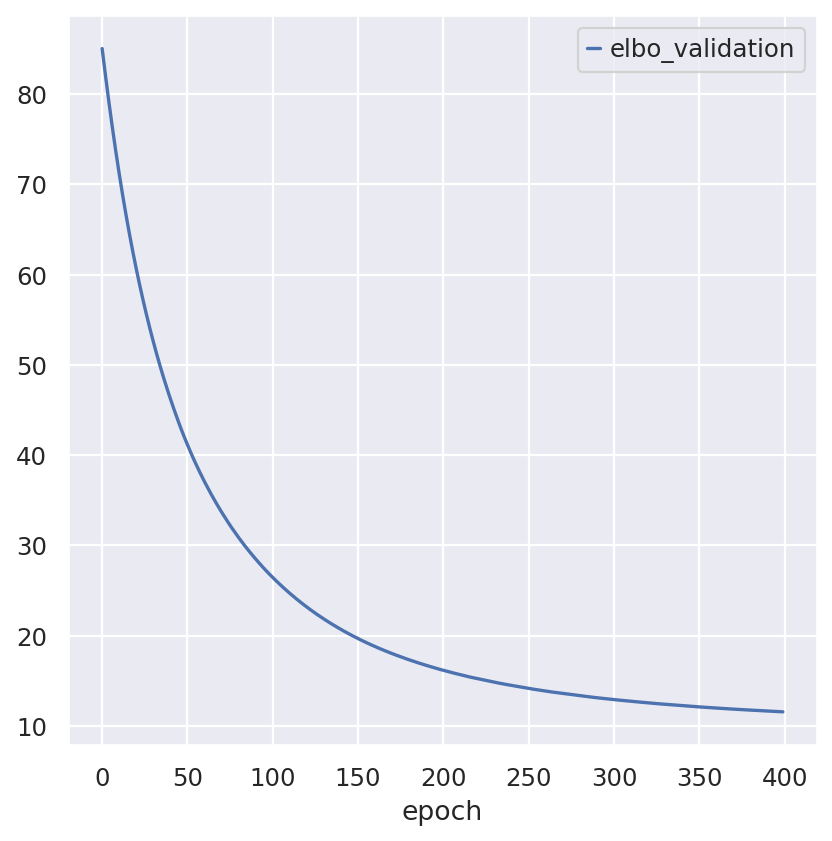

In [24]:
l1_model.history["elbo_validation"].plot()

In [25]:
predictions = l1_model.predict()
predictions.head()

Cell type,G2/M phase,S phase,bundle sheath,cambium,companion cell,epidermis,guard cell,meristem,mesophyll,myrosin idioblasts,pavement cell,phloem,phloem parenchyma,proliferating cell,sieve element,tracheary element,vasculature,xylem,unknown
0,0.001240,0.000112,0.000504,0.000211,0.000063,4.491851e-07,0.000079,0.000051,1.284249e-05,0.000008,2.336347e-07,0.000098,0.000043,0.000020,2.089265e-06,0.000164,0.000017,0.990270,0.007105
1,0.001253,0.000138,0.000510,0.000213,0.000067,6.559559e-07,0.000082,0.000055,1.105879e-05,0.000008,3.632976e-07,0.000104,0.000046,0.000024,3.126664e-06,0.000166,0.000212,0.989924,0.007184
2,0.001197,0.000055,0.000487,0.000204,0.000052,2.998417e-07,0.000070,0.000042,9.448491e-06,0.000006,7.506973e-08,0.000082,0.000533,0.000012,6.280175e-07,0.000158,0.001949,0.988279,0.006864
3,0.001204,0.000249,0.000490,0.000205,0.000053,8.170185e-06,0.000071,0.000043,9.374542e-09,0.000006,8.400846e-08,0.000084,0.000037,0.000013,7.174537e-07,0.000159,0.000217,0.990259,0.006902
4,0.001234,0.000442,0.000502,0.000210,0.000063,4.438795e-07,0.000079,0.000052,5.424373e-05,0.000008,2.561586e-07,0.000098,0.000044,0.000021,2.276724e-06,0.000163,0.006436,0.983515,0.007075


/opt/conda/lib/python3.11/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)
/opt/conda/lib/python3.11/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)


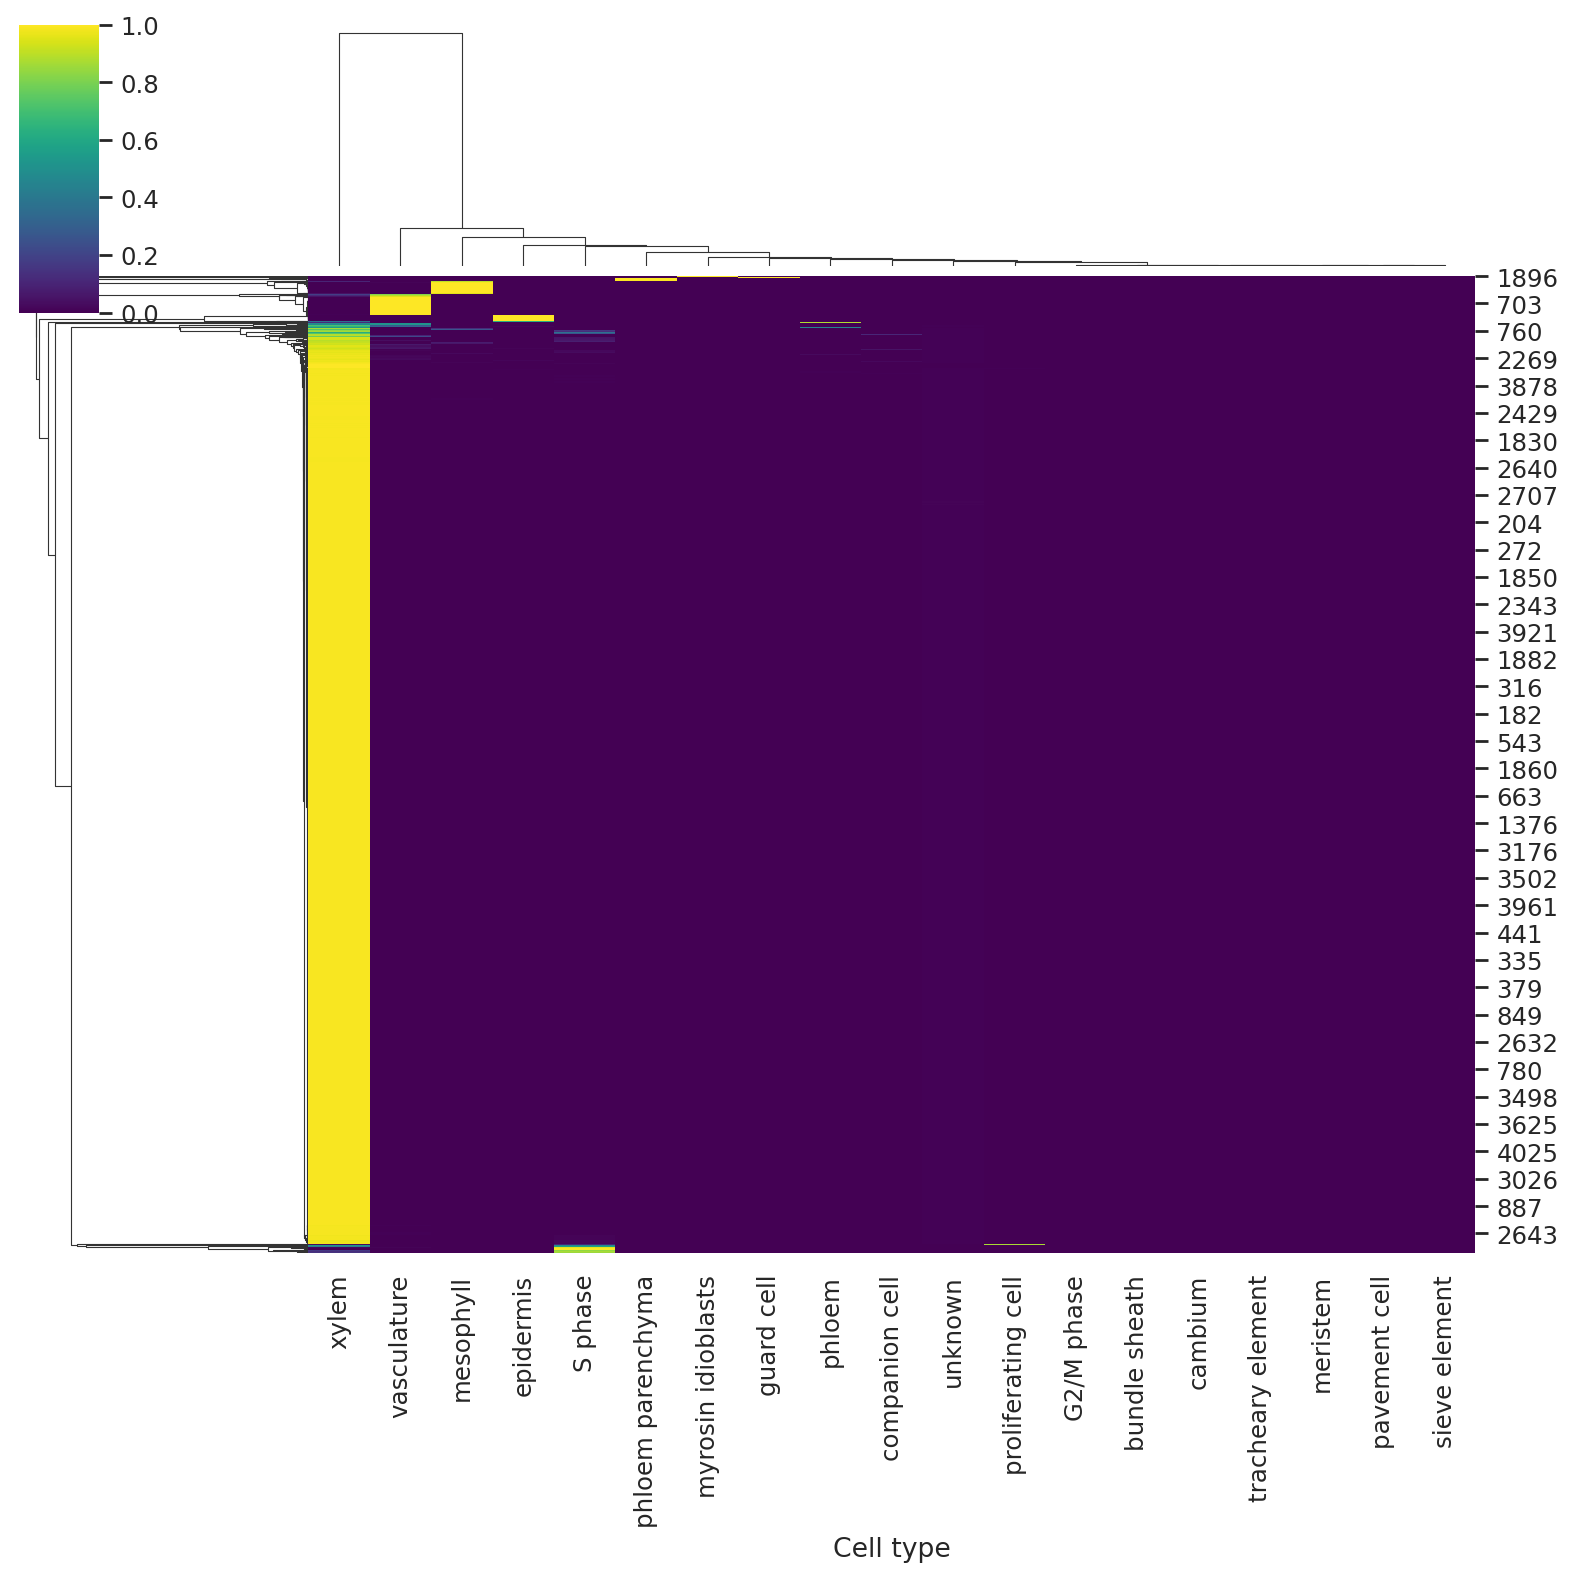

In [26]:
sns.clustermap(predictions, cmap="viridis")

In [27]:
l1_bdata.obs["cellassign_predictions_2"] = predictions.idxmax(axis=1).values

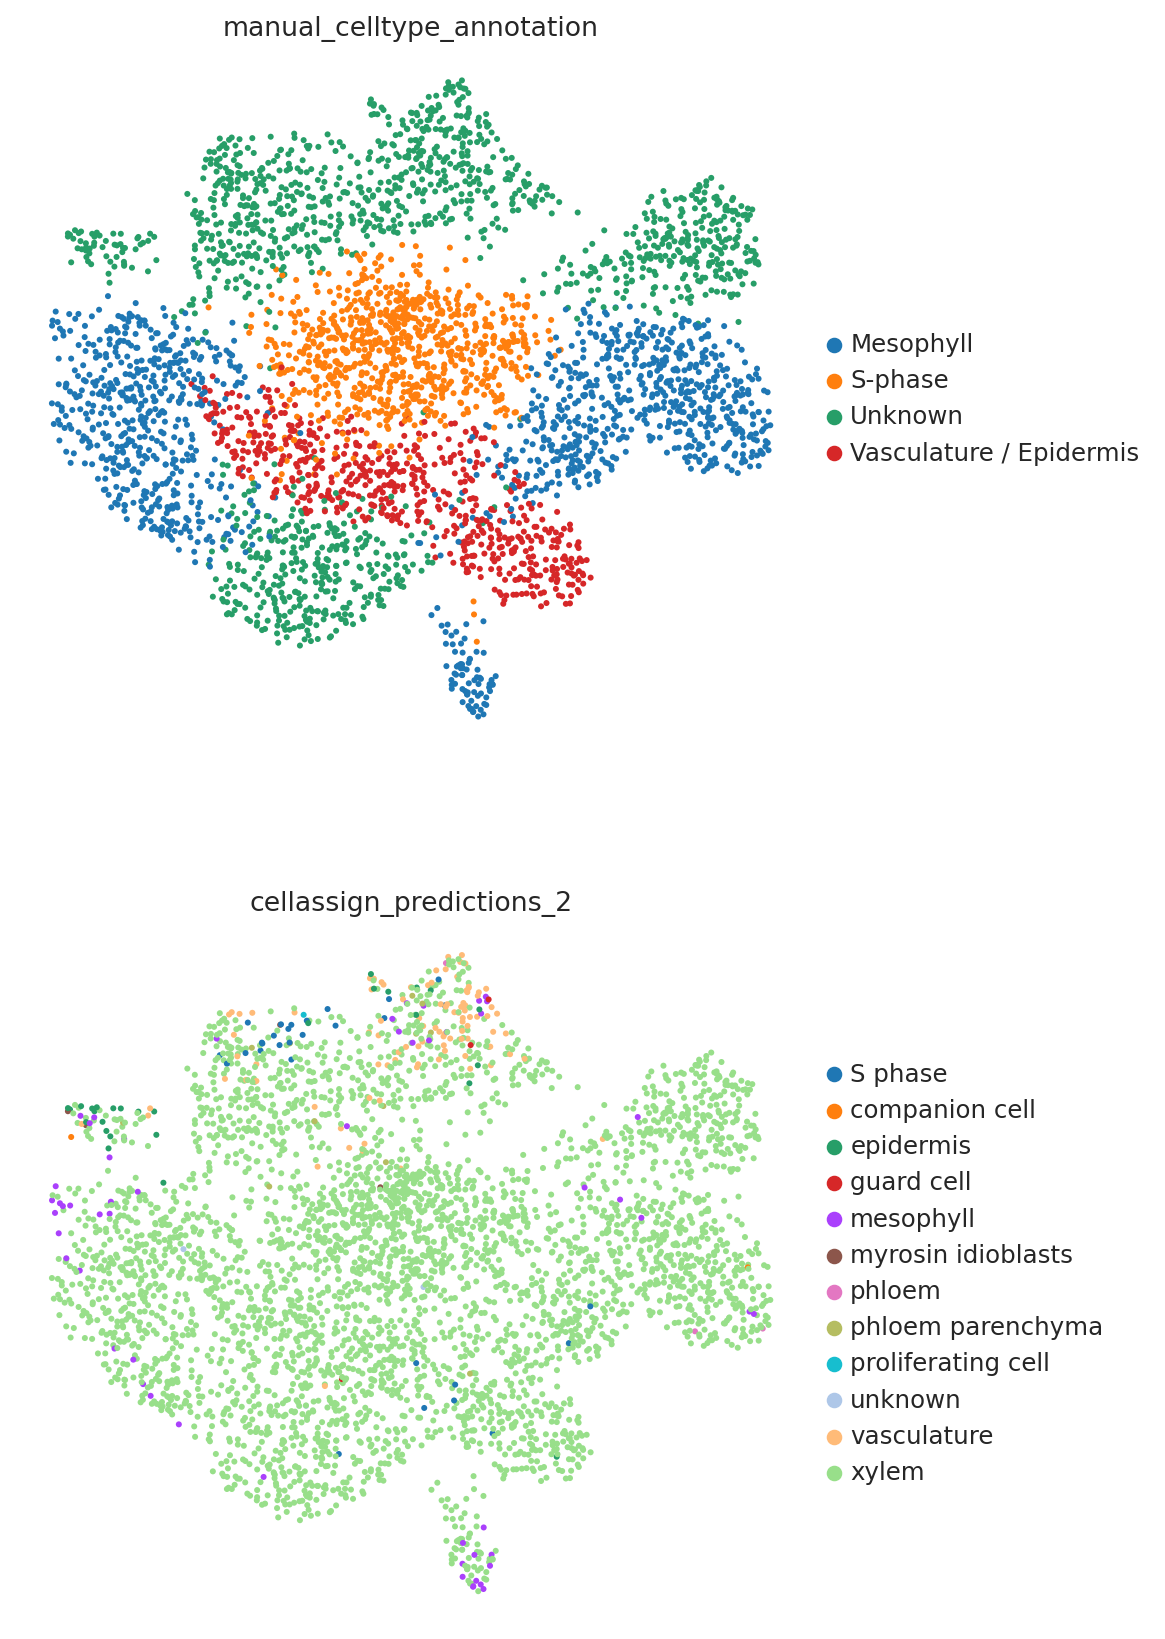

In [28]:
# celltype is the original CellAssign prediction
sc.pl.umap(
    l1_bdata,
    color=["manual_celltype_annotation", "cellassign_predictions_2"],
    frameon=False,
    ncols=1,
)

## L2 on SoupX layer

In [29]:
scvi.external.CellAssign.setup_anndata(l2_bdata, layer='soupX_counts', size_factor_key="size_factors")

In [30]:
l2_model = CellAssign(l2_bdata, celltype_markers.loc[shared_genes_l2, :])
l2_model.train()

GPU available: False, used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
/opt/conda/lib/python3.11/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:424: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=23` in the `DataLoader` to improve performance.
/opt/conda/lib/python3.11/site-packages/lightning/pytorch/loops/fit_loop.py:298: The number of training batches (3) is smaller than the logging interval Trainer(log_every_n_steps=10). Set a lower value for log_every_n_steps if you want to see logs for the training epoch.
/opt/conda/lib/python3.11/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:424: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=23` in the `DataLoader` to improve performance.


Epoch 1/400:   0%|          | 0/400 [00:00<?, ?it/s]

Epoch 400/400: 100%|██████████| 400/400 [08:57<00:00,  1.26s/it, v_num=1, train_loss_step=16.9, train_loss_epoch=16.9]

`Trainer.fit` stopped: `max_epochs=400` reached.


Epoch 400/400: 100%|██████████| 400/400 [08:57<00:00,  1.34s/it, v_num=1, train_loss_step=16.9, train_loss_epoch=16.9]


<Axes: xlabel='epoch'>

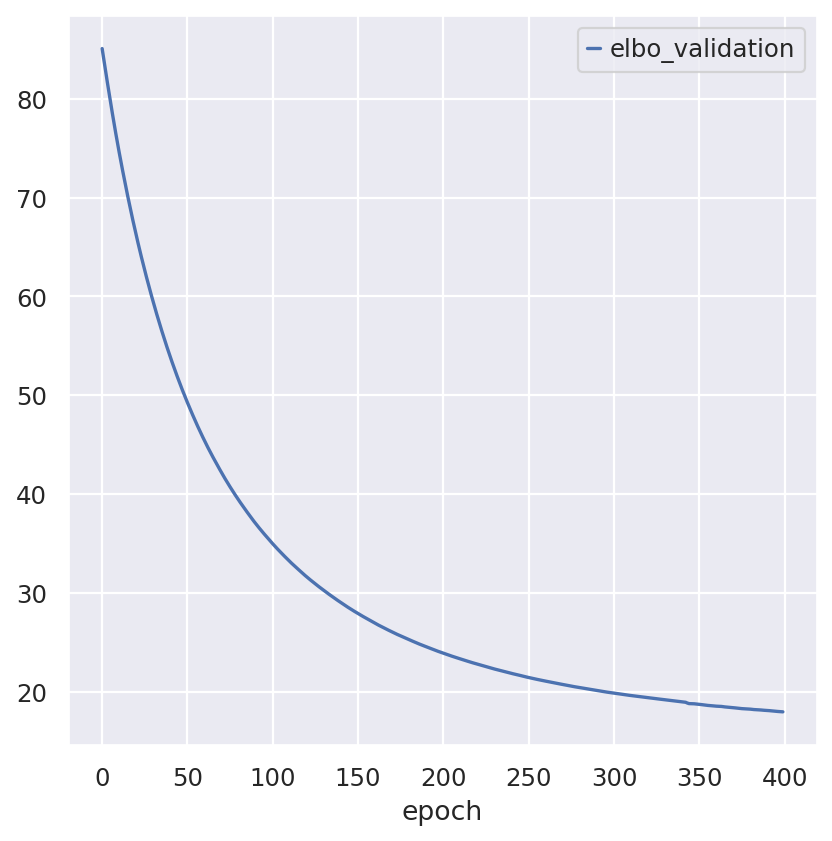

In [31]:
l2_model.history["elbo_validation"].plot()

In [32]:
predictions = l2_model.predict()
predictions.head()

Cell type,G2/M phase,S phase,bundle sheath,cambium,companion cell,epidermis,guard cell,meristem,mesophyll,myrosin idioblasts,pavement cell,phloem,phloem parenchyma,proliferating cell,sieve element,tracheary element,vasculature,xylem,unknown
0,0.994808,0.000024,0.002342,2.195711e-06,0.000016,1.532643e-08,5.440815e-07,0.000023,0.000050,0.000060,0.000104,0.000115,0.000131,0.000079,0.000007,4.144200e-06,5.967157e-07,0.000150,0.002084
1,0.994273,0.000012,0.002340,7.159646e-07,0.000010,7.806142e-08,2.086208e-07,0.000014,0.000034,0.000040,0.000072,0.000094,0.000107,0.000067,0.000003,1.332545e-06,7.339739e-04,0.000117,0.002083
2,0.994721,0.000030,0.002341,3.366910e-06,0.000019,2.949264e-06,8.475491e-07,0.000027,0.000058,0.000068,0.000116,0.000124,0.000141,0.000084,0.000010,6.148364e-06,2.474816e-07,0.000164,0.002084
3,0.995095,0.000007,0.002342,4.223652e-07,0.000006,6.067800e-08,1.586091e-07,0.000009,0.000026,0.000030,0.000055,0.000084,0.000095,0.000061,0.000001,7.064759e-07,4.683060e-07,0.000101,0.002085
4,0.989421,0.005560,0.002329,1.027490e-06,0.000012,7.112122e-08,2.728535e-07,0.000016,0.000038,0.000046,0.000082,0.000100,0.000114,0.000071,0.000004,1.962171e-06,4.194173e-06,0.000126,0.002073


/opt/conda/lib/python3.11/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)
/opt/conda/lib/python3.11/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)


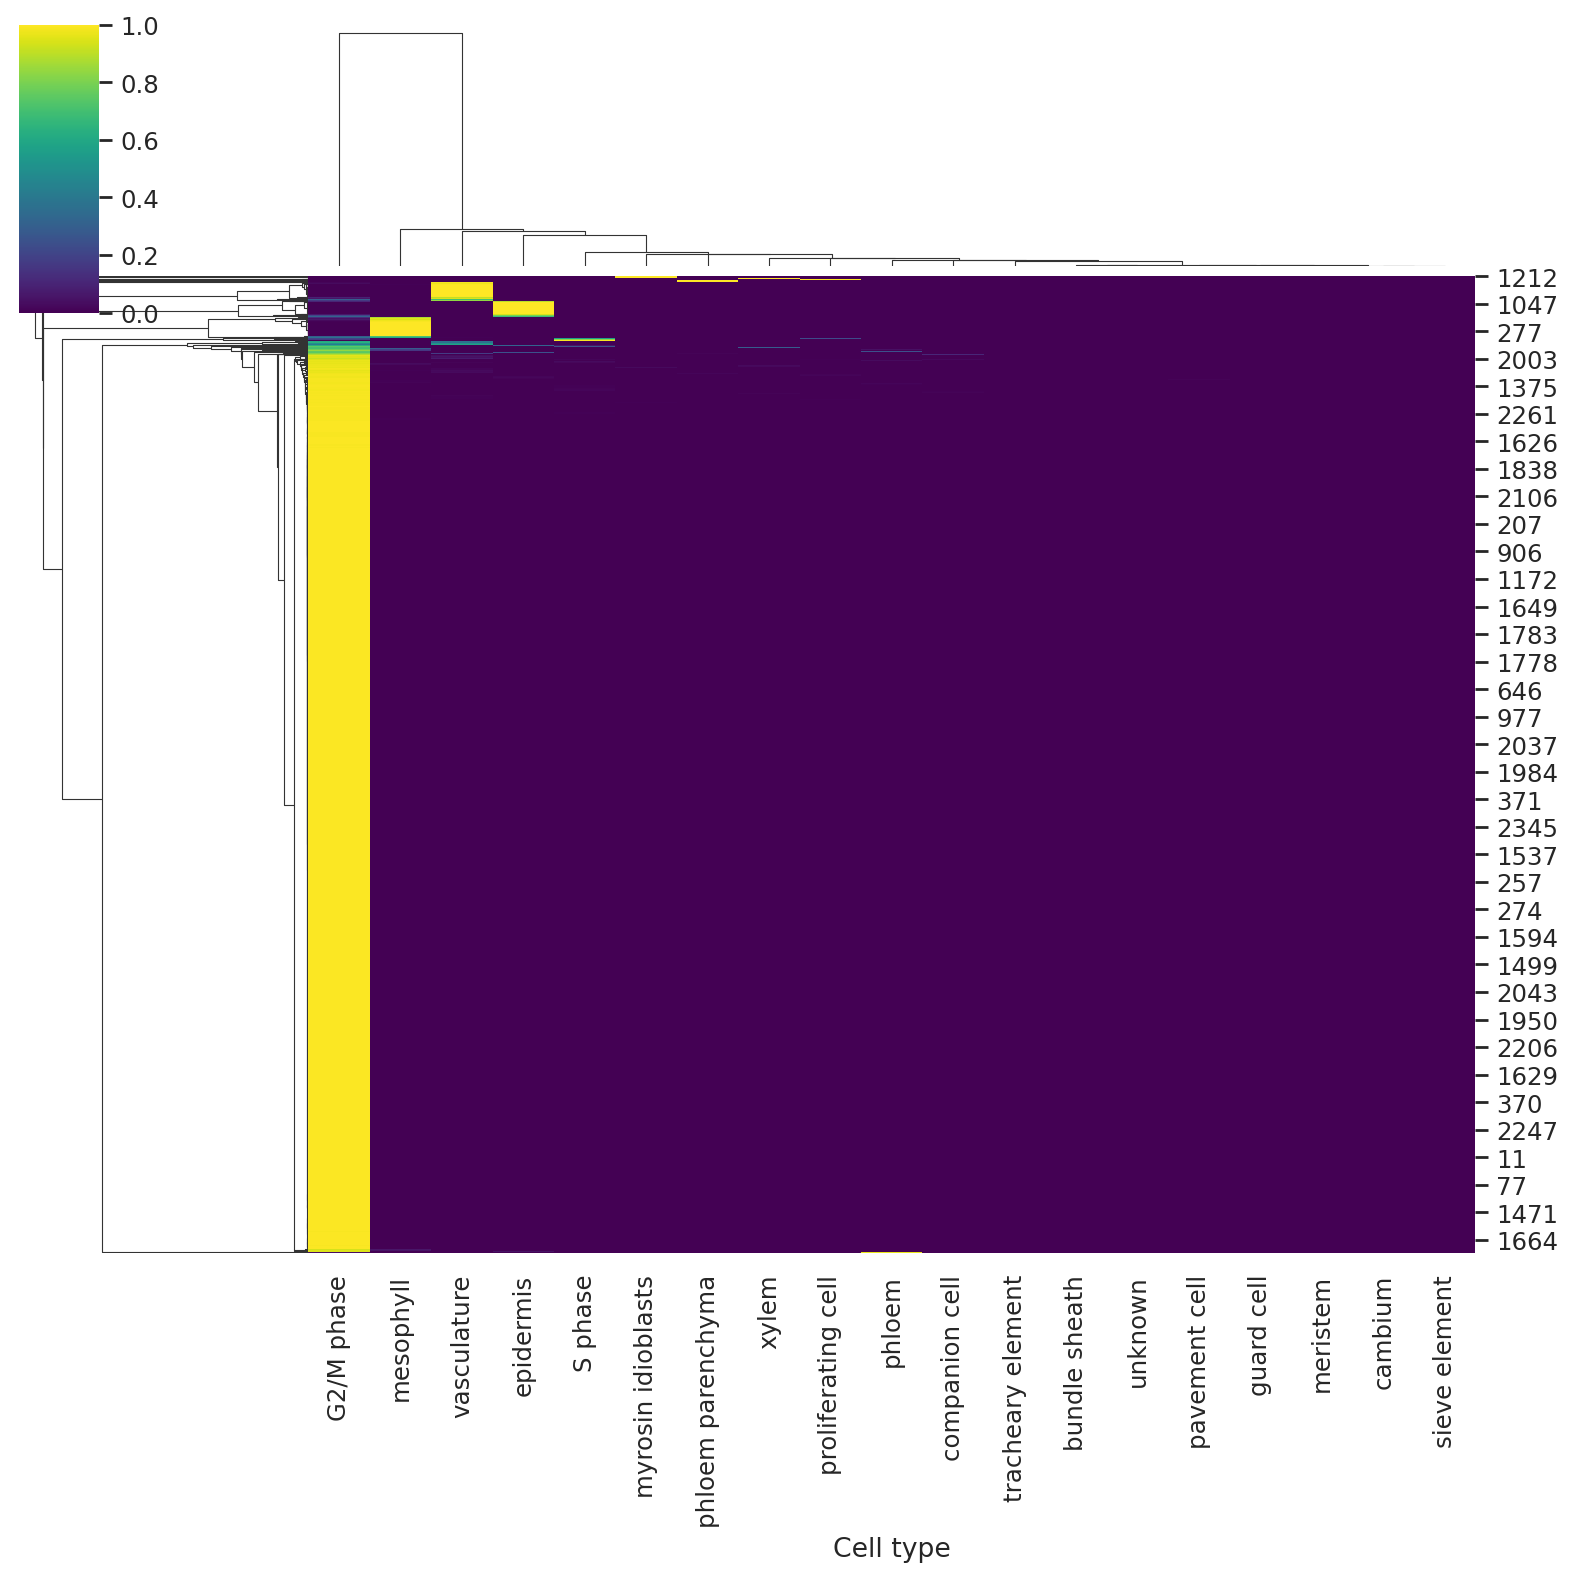

In [33]:
sns.clustermap(predictions, cmap="viridis")

In [34]:
l2_bdata.obs["cellassign_predictions_2"] = predictions.idxmax(axis=1).values

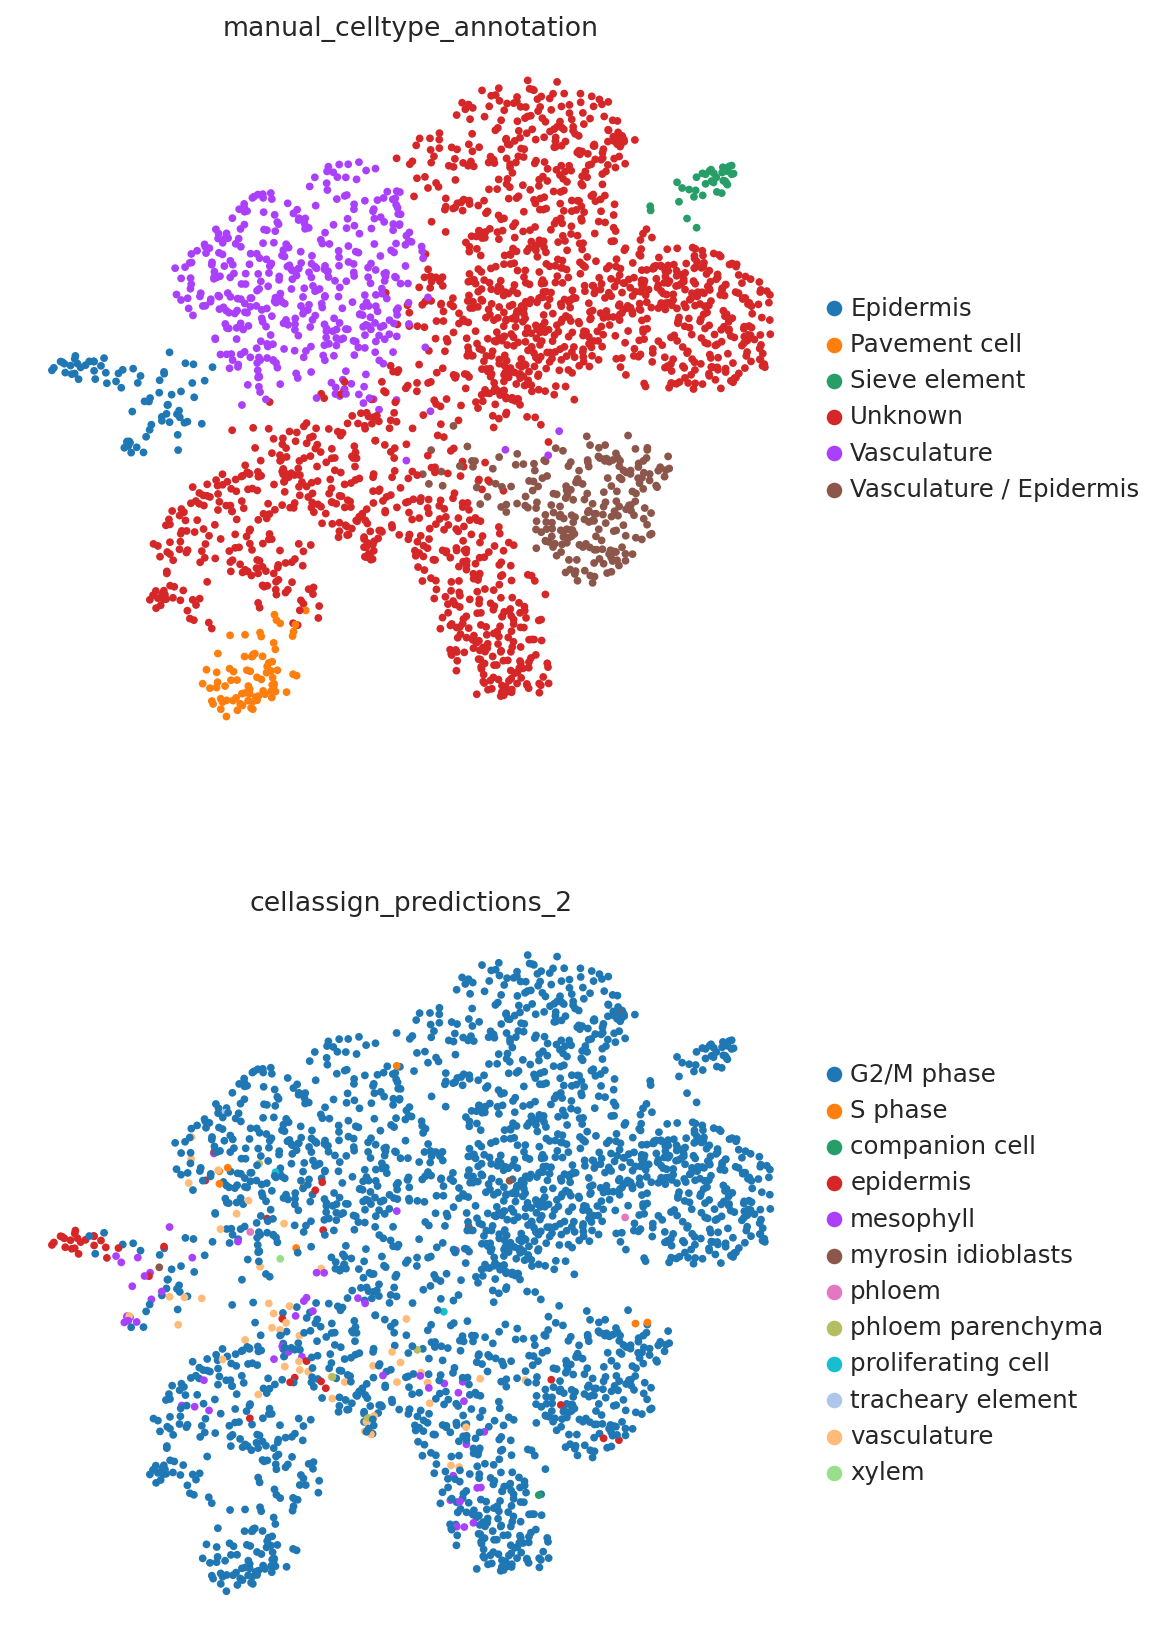

In [35]:
# celltype is the original CellAssign prediction
sc.pl.umap(
    l2_bdata,
    color=["manual_celltype_annotation", "cellassign_predictions_2"],
    frameon=False,
    ncols=1,
)

In [36]:
l1.write("L1_annotation.h5ad")
l2.write("L2_annotation.h5ad")